# Support vector machine

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("../datasets/Iris.csv").drop(columns="Id")
df = df.head(100)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,Iris-versicolor
96,5.7,2.9,4.2,1.3,Iris-versicolor
97,6.2,2.9,4.3,1.3,Iris-versicolor
98,5.1,2.5,3.0,1.1,Iris-versicolor


In [41]:
df["Species"] = df.iloc[:, 4].apply(lambda x: -1 if x=="Iris-setosa" else 1)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,-1
1,4.9,3.0,1.4,0.2,-1
2,4.7,3.2,1.3,0.2,-1
3,4.6,3.1,1.5,0.2,-1
4,5.0,3.6,1.4,0.2,-1
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


In [42]:
#df = df.sample(frac=1, random_state=21)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,-1
1,4.9,3.0,1.4,0.2,-1
2,4.7,3.2,1.3,0.2,-1
3,4.6,3.1,1.5,0.2,-1
4,5.0,3.6,1.4,0.2,-1
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


Решил пока не разделять выборку на тестовую и тренировочную, а сразу обучать на полной. Потом заполним выборку выбросами и посмотрим как она будет работать.

In [43]:
x_train = np.array(df.drop(columns="Species"))

y_train = np.array(df["Species"])
x_train

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [44]:
class SVM():
    def __init__(self):
        self.w = None
        self.alpha = 0.0001
        self.regul = 0.001
        self.size_features = None
        
    def add_bias(self, x):          #Добавляем отдельную колонку в матрицу фич для определения весов баеса
        self.size_features = x.shape
        new_arr = np.ones([self.size_features[0], 1])
        x = np.hstack((x, new_arr))
        print("Bias has been added to the feature matrix\n")
        self.size_features = x.shape
        return x

    def fit(self, x, y):
        self.w = np.zeros([self.size_features[1], 1])
        counter = 0
        list_of_loss = list()
        list_of_grad = list()
        prev_loss = 10000
        #for j in range(10000):    #цикл по эпохам
        while True:
            for i in range(self.size_features[0]):
                margin = y[i]*(np.dot(x[i], self.w))
                if margin < 1:
                    grad = -y[i]*x[i] + np.dot(self.w.T, self.regul)
                else:
                    grad = np.dot(self.w.T, self.regul)
                self.w = self.w - self.alpha * grad.T
            
                # Найдем функцию потерь, чтобы потом проанализировать график кривой обучения:
                if 0 > (1 - margin):
                    loss = self.regul * np.dot(self.w.T, self.w) / 2
                else:
                    loss = (1 - margin) + (self.regul * np.dot(self.w.T, self.w) / 2)

            counter+=1
            list_of_loss.append([counter, loss])
            list_of_grad.append([counter, np.linalg.norm(grad)])

            #Условие выхода: градиент равен 0
            if np.linalg.norm(grad) < 1e-4:
                break
            #Условие выхода: функция потерь перестала меняться
            if abs(loss - prev_loss) < 1e-5:
                break
            prev_loss = loss

        self.list_of_loss = list_of_loss
        self.list_of_grad = list_of_grad
        print(f"Weights:\n{self.w}")
        return self.w
    
    def plot_loss(self):
        iterations = list()
        loss_function = list()
        for obj in self.list_of_loss:
            iterations.append(obj[0])
            axis_y = obj[1]
            loss_function.append(axis_y[0])
        fig, ax = plt.subplots(figsize=(15, 8))
        plt.plot(iterations, loss_function, color="deepskyblue")
        ax.set_xlabel("Iterations (epochs)")
        ax.set_ylabel("Loss function")
        ax.grid(axis="y")
        ax.set_title("Convergence of gradient descent")
        return ax
    
    def predict(self, x):
        y_pred = np.sign(np.dot(x, self.w))
        return y_pred

In [45]:
svc = SVM()
x_train = svc.add_bias(x_train)
w = svc.fit(x_train, y_train)

Bias has been added to the feature matrix

Weights:
[[-0.09660963]
 [-0.37451197]
 [ 0.57503231]
 [ 0.24543871]
 [-0.06367978]]


In [46]:
svc.list_of_loss

[[1, array([[0.92419819]])],
 [2, array([[0.84241446]])],
 [3, array([[0.7606318]])],
 [4, array([[0.67885022]])],
 [5, array([[0.59706971]])],
 [6, array([[0.51529028]])],
 [7, array([[0.43351192]])],
 [8, array([[0.35173464]])],
 [9, array([[0.26995843]])],
 [10, array([[0.18818329]])],
 [11, array([[0.10640923]])],
 [12, array([[0.05163475]])],
 [13, array([[0.02305152]])],
 [14, array([[0.01384434]])],
 [15, array([[0.01700415]])],
 [16, array([[0.02016407]])],
 [17, array([[0.02332409]])],
 [18, array([[0.01995933]])],
 [19, array([[0.02265262]])],
 [20, array([[0.02534603]])],
 [21, array([[0.02803954]])],
 [22, array([[0.03073315]])],
 [23, array([[0.03342688]])],
 [24, array([[0.03612071]])],
 [25, array([[0.03881466]])],
 [26, array([[0.0415087]])],
 [27, array([[0.03782496]])],
 [28, array([[0.04051327]])],
 [29, array([[0.04320169]])],
 [30, array([[0.04589021]])],
 [31, array([[0.04857884]])],
 [32, array([[0.0448957]])],
 [33, array([[0.04758461]])],
 [34, array([[0.050273

In [47]:
csv1 = pd.Series(svc.list_of_loss)
csv1.to_csv("Log_loss.csv", index=False, header=False)
csv2 = pd.Series(svc.list_of_grad)
csv2.to_csv("Log_grad.csv", index=False, header=False)
csv1

0          [1, [[0.9241981940590366]]]
1          [2, [[0.8424144621889477]]]
2          [3, [[0.7606318049721499]]]
3          [4, [[0.6788502223927605]]]
4           [5, [[0.597069714434897]]]
                    ...               
62      [63, [[0.011102797935805599]]]
63      [64, [[0.014081967506436468]]]
64      [65, [[0.004441807386931042]]]
65    [66, [[0.00026783899969280456]]]
66    [67, [[0.00027227503579580457]]]
Length: 67, dtype: object

<Axes: title={'center': 'Convergence of gradient descent'}, xlabel='Iterations (epochs)', ylabel='Loss function'>

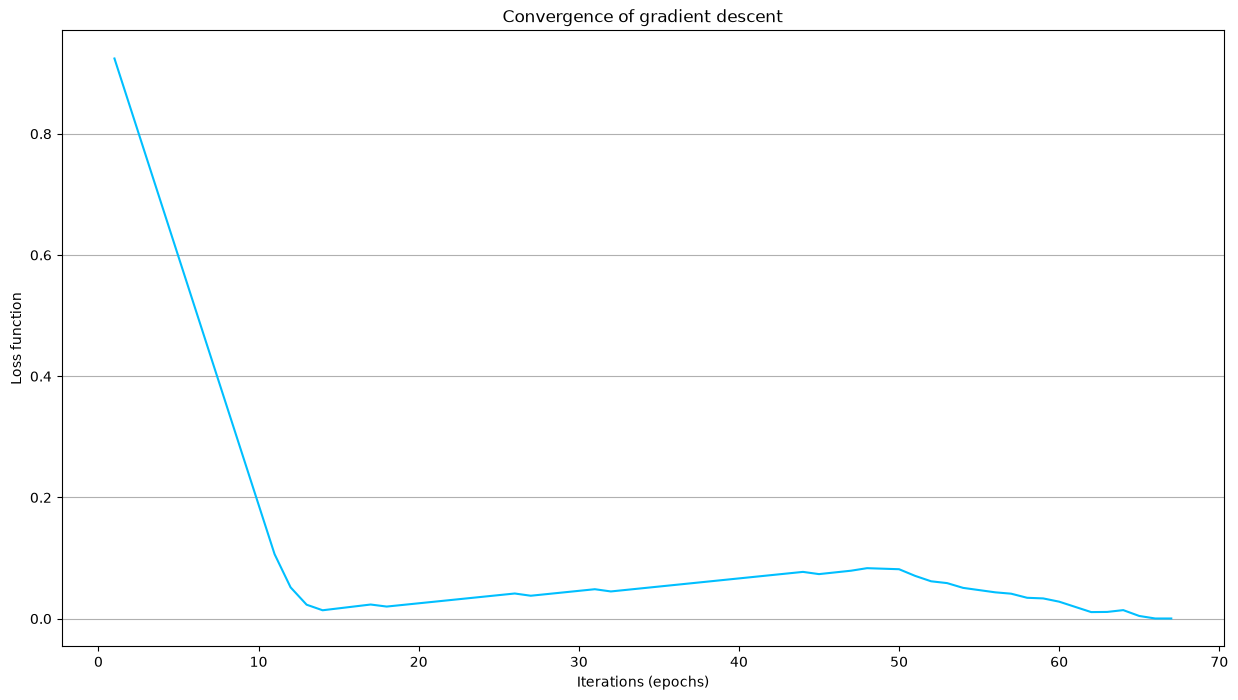

In [48]:
svc.plot_loss()

In [49]:
pred = svc.predict(x_train)
pred = pd.DataFrame(pred, columns=["Predict"], dtype='int')
checker_df = pd.concat([df, pred], axis=1)
checker_df.head(50)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predict
0,5.1,3.5,1.4,0.2,-1,-1
1,4.9,3.0,1.4,0.2,-1,-1
2,4.7,3.2,1.3,0.2,-1,-1
3,4.6,3.1,1.5,0.2,-1,-1
4,5.0,3.6,1.4,0.2,-1,-1
5,5.4,3.9,1.7,0.4,-1,-1
6,4.6,3.4,1.4,0.3,-1,-1
7,5.0,3.4,1.5,0.2,-1,-1
8,4.4,2.9,1.4,0.2,-1,-1
9,4.9,3.1,1.5,0.1,-1,-1


In [50]:
accuracy_arr = (abs(checker_df["Species"]) - abs(checker_df["Predict"]))
true_pred = len(accuracy_arr[accuracy_arr == 0]) #количество верных
accuracy = true_pred / len(checker_df["Species"]) * 100 
print(f"Точность проноза составляет {accuracy}%")

Точность проноза составляет 100.0%


## Сверим результат с работой библиотеки sklearn

In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

clf = SVC(kernel='linear')
clf.fit(x_train, y_train)
clf.coef_, w

(array([[ 4.62585381e-02, -5.21182800e-01,  1.00304462e+00,
          4.64129785e-01,  1.11022302e-16]]),
 array([[-0.09660963],
        [-0.37451197],
        [ 0.57503231],
        [ 0.24543871],
        [-0.06367978]]))

In [52]:
checker_df["Sklearn predict"] = clf.predict(x_train)

In [53]:
checker_df.head(50)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predict,Sklearn predict
0,5.1,3.5,1.4,0.2,-1,-1,-1
1,4.9,3.0,1.4,0.2,-1,-1,-1
2,4.7,3.2,1.3,0.2,-1,-1,-1
3,4.6,3.1,1.5,0.2,-1,-1,-1
4,5.0,3.6,1.4,0.2,-1,-1,-1
5,5.4,3.9,1.7,0.4,-1,-1,-1
6,4.6,3.4,1.4,0.3,-1,-1,-1
7,5.0,3.4,1.5,0.2,-1,-1,-1
8,4.4,2.9,1.4,0.2,-1,-1,-1
9,4.9,3.1,1.5,0.1,-1,-1,-1


In [54]:
accuracy = accuracy_score(y_true=checker_df['Species'], y_pred=checker_df['Sklearn predict'])
print(f"Точность проноза составляет {accuracy*100}%")

Точность проноза составляет 100.0%


In [55]:
conf_matrix = confusion_matrix(y_true=checker_df['Species'], y_pred=checker_df['Sklearn predict'])
conf_matrix

array([[50,  0],
       [ 0, 50]])

In [56]:
f1 = f1_score(y_true=checker_df['Species'], y_pred=checker_df['Sklearn predict'])
print(f"Точность проноза составляет {f1*100}%")

Точность проноза составляет 100.0%


### Распознавание нескольких классов с sklearn

In [57]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

x, y = load_iris(return_X_y=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=21)

clf = SVC()
clf.fit(x_train, y_train)
predict = pd.Series(clf.predict(x_train))

df_train = pd.DataFrame(x_train)
df_train = pd.concat([df_train, pd.Series(y_train), predict], axis=1)

df_train.columns = ["feature1","feature2","feature3","feature4","target", "predict with SVC()"]
df_train.head(50)

,feature1,feature2,feature3,feature4,target,predict with SVC()
0,4.4,3.0,1.3,0.2,0,0
1,5.8,2.7,5.1,1.9,2,2
2,5.9,3.0,5.1,1.8,2,2
3,6.3,3.4,5.6,2.4,2,2
4,5.7,2.5,5.0,2.0,2,2
5,6.2,2.9,4.3,1.3,1,1
6,6.9,3.1,5.1,2.3,2,2
7,5.5,3.5,1.3,0.2,0,0
8,4.9,3.6,1.4,0.1,0,0
9,4.3,3.0,1.1,0.1,0,0


In [58]:
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

OVR_clf = OneVsRestClassifier(SVC())
OVR_clf.fit(x_train, y_train)
OVR_predict = OVR_clf.predict(x_train)

df_train = pd.concat([df_train, pd.Series(OVR_predict, name='OVR SVC')], axis=1)
# df_train.columns.values[6] = 'OVR SVC'

OVO_clf = OneVsOneClassifier(SVC())
OVO_clf.fit(x_train, y_train)
OVO_predict = OVO_clf.predict(x_train)

df_train = pd.concat([df_train, pd.Series(OVO_predict, name='OVO SVC')], axis=1)
# df_train.columns.values[7] = 'OVO SVC'
df_train.head(50)

,feature1,feature2,feature3,feature4,target,predict with SVC(),OVR SVC,OVO SVC
0,4.4,3.0,1.3,0.2,0,0,0,0
1,5.8,2.7,5.1,1.9,2,2,2,2
2,5.9,3.0,5.1,1.8,2,2,2,2
3,6.3,3.4,5.6,2.4,2,2,2,2
4,5.7,2.5,5.0,2.0,2,2,2,2
5,6.2,2.9,4.3,1.3,1,1,1,1
6,6.9,3.1,5.1,2.3,2,2,2,2
7,5.5,3.5,1.3,0.2,0,0,0,0
8,4.9,3.6,1.4,0.1,0,0,0,0
9,4.3,3.0,1.1,0.1,0,0,0,0
